In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

from seqAE_model import SeqAutoencoder
from contra_seq_dataset import AnchoredSampler
from torch.utils.data import DataLoader, RandomSampler
from contra_seq_dataset import ContraSeqDataset, get_dataset_array, get_anc_map
from losses import SupConLoss, padce_loss
from tqdm.notebook import tqdm
import torch
import random

In [2]:
## Dataset

anc_path = 'model_dataset/anchor_smiles.csv'
aug_path = 'model_dataset/augmented_smiles_balanced.csv'

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

In [3]:
import torch.nn as nn
import pandas as pd
import matplotlib.pylab as plt

# torch.cuda.empty_cache()
use_cuda = False
device =  torch.device("cuda" if use_cuda else "cpu")
supcon_loss = SupConLoss()
lr = 0.00001

model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

p = 'models/supconrecon_20220412a/checkpoint_supconrecon_20220412a_49'
model.load_state_dict(torch.load(p), strict = False)

if use_cuda==True and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model)
    model.to(device)
else:
    model = model.to(device)
    
optimizer = torch.optim.Adam(model.parameters(), lr = lr)    
model.eval()

SeqAutoencoder(
  (embedder): Embedding(31, 512)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (enc): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=0.6, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=0.6, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
      (1): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )

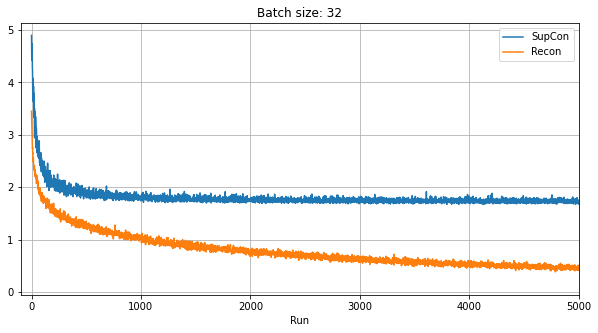

In [4]:
import seaborn as sns
losses = pd.read_csv('training_logs/losses_20220412a',usecols=['SupCon','Recon'])

BATCH_SIZE = 32

figsize=(10,5)
plt.figure(figsize=figsize)
for label,data in losses.iteritems():
    plt.plot(data, label=label)

plt.xlim(-100,5000)
plt.title(f'Batch size: {BATCH_SIZE}')
plt.grid(True)
plt.xlabel('Run')
plt.legend(loc='upper right')
plt.show()

## UMAP a sample of training data.

In [5]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
import numpy as np
import copy

_df = copy.deepcopy(ds_arr)
_df.columns = ['Smiles','Atype','Label'] # [x[0].upper() + x[1:] for x in df.columns]

num_to_eval = 500
rand = random.sample(range(0,len(_df)),num_to_eval)
# np.savetxt("20220412_rand_500.txt", rand)
rand_idc = np.concatenate([anc_map[x] for x in rand],axis=0)

df = _df.iloc[rand_idc]
display(df)

from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype"]]
# display(df)

,Smiles,Atype,Label
6671,CC(CS)C(=O)N(CC(=O)O)SC1CCCC1,Anc,6671
33355,CC(C(=O)N(CC(=O)O)SC1CCCC1)C(N)S,Aug,6671
33356,CC(CS)C(=O)N(CC(=O)O)SC1CCCC1S,Aug,6671
33357,CC1CCC(SN(CC(=O)O)C(=O)C(C)CS)C1,Aug,6671
33358,CC(CS)C(=O)N(CC(=O)O)SC1CCCC1N,Aug,6671
...,...,...,...
40655,CCC(N)C(=O)c1cnn(-c2ccc(N)nc2)c1C,Aug,8131
40656,CCCC(=O)c1cnn(-c2cnc(N)c(N)c2)c1C,Aug,8131
40657,CCCC(=O)c1c(C)nn(-c2ccc(N)nc2)c1C,Aug,8131
40658,CCCC(=O)c1cnn(-c2ccc(N)nc2)c1CN,Aug,8131


### Get latent code from model.

In [6]:
sampler = AnchoredSampler(rand, anc_map, num_to_eval, drop_last = False)
loader = DataLoader(ds, batch_sampler=sampler, num_workers=0, pin_memory=True)

for samp in loader:
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                                    samp['avg_mask'], samp['out_mask'])
    latent = torch.nn.functional.normalize(latent, p=2.0, dim=1)
latent = latent.detach().numpy()
print(latent.shape)

(3000, 32)


In [7]:
# torch.cuda.empty_cache()

In [8]:
import umap.umap_ as umap
umapper = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=2, metric='euclidean')
embedding = umapper.fit_transform(latent)

df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,Smiles,Mol,Label,Atype,x,y
6671,CC(CS)C(=O)N(CC(=O)O)SC1CCCC1,,6671,Anc,-3.214338,1.483015
33355,CC(C(=O)N(CC(=O)O)SC1CCCC1)C(N)S,,6671,Aug,-3.229130,1.475111
33356,CC(CS)C(=O)N(CC(=O)O)SC1CCCC1S,,6671,Aug,-3.211150,1.483261
33357,CC1CCC(SN(CC(=O)O)C(=O)C(C)CS)C1,,6671,Aug,-3.214048,1.480715
33358,CC(CS)C(=O)N(CC(=O)O)SC1CCCC1N,,6671,Aug,-3.217686,1.480680
...,...,...,...,...,...,...
40655,CCC(N)C(=O)c1cnn(-c2ccc(N)nc2)c1C,,8131,Aug,8.814031,0.497243
40656,CCCC(=O)c1cnn(-c2cnc(N)c(N)c2)c1C,,8131,Aug,8.807166,0.511376
40657,CCCC(=O)c1c(C)nn(-c2ccc(N)nc2)c1C,,8131,Aug,8.819349,0.503771
40658,CCCC(=O)c1cnn(-c2ccc(N)nc2)c1CN,,8131,Aug,8.805095,0.517522

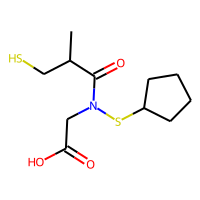
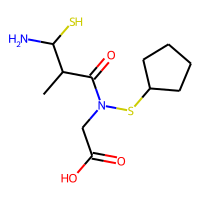
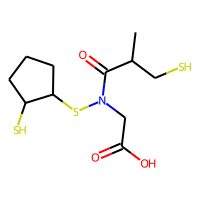
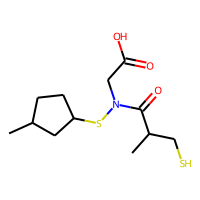
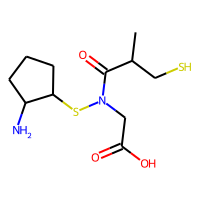
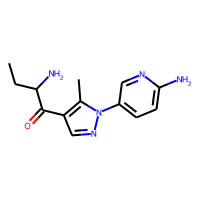
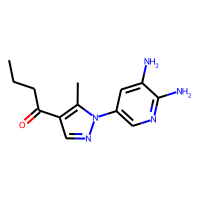
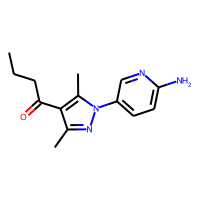
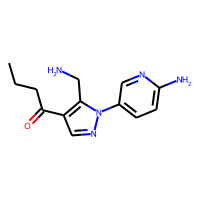
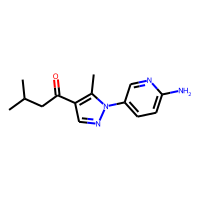

In [22]:
df

In [ ]:
coords = df[['x','y']]

In [21]:
%matplotlib inline
import plotly.graph_objs as go

from ipywidgets import Image, Layout, HBox, VBox
from rdkit.Chem import Draw
import PIL

import ipywidgets as widgets
import io

# df_anchors = df[df.Atype=='Anc']
# df_augmentations = df[df.Atype=='Aug']

# Assemble all the traces.
trace_anchors = (go.Scattergl(x=df[df.Atype=='Anc']['x'], 
                           y=df[df.Atype=='Anc']['y'], 
                           name='Anchors',
                           marker=dict(size=3, opacity=1., color='blue'),
                           hoverinfo='text',
                           text=df[df.Atype=='Anc']['Smiles'],
                           mode='markers'))
trace_augmentations = (go.Scattergl(x=df[df.Atype=='Aug']['x'], 
                           y=df[df.Atype=='Aug']['y'], 
                           name='Augmentations',
                           marker=dict(size=5, opacity=0.5, color='red'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Atype=='Aug']['Smiles'],
                           mode='markers'))
data = [trace_augmentations, trace_anchors, ]

# Make figure.
fig = go.FigureWidget(data=data)
# fig.layout.hovermode = 'closest'
fig.update_layout(template='simple_white', autosize=False, height=512)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1.)

# Show-mol-on-hover function.
img = open('white.png','rb').read()
# img = PIL.Image.new('1', (256, 256)).tobytes()
image_widget = Image(value=img)

def hover_fn(trace, points, state):
    
    if points.point_inds:
        if trace['name']=='Anchors':
            my_df = df[df.Atype=='Anc']
        elif trace['name']=='Augmentations':
            my_df = df[df.Atype=='Aug']
            
        idx = points.point_inds[0]
        datum = my_df.iloc[idx]
        mol = datum.Mol

        img = Draw.MolToImage(mol,size=(256, 512))  ### to make mol image smaller, alter first dim. 
        imgByteArr = io.BytesIO()
        img.save(imgByteArr, format='PNG')
        imgByteArr = imgByteArr.getvalue()
        image_widget.value = imgByteArr

for trace_num in range(len(fig.data)):
    fig.data[trace_num].on_hover(hover_fn)  
HBox([HBox([image_widget]),fig])